# Phase 2 — Autograd (Automatic Differentiation)

At the end of Phase 1 we hit a wall: we could compute a **loss** (how wrong
a prediction is), but not the **gradient** (which direction, and by how
much, to nudge each parameter to reduce that loss).

Autograd is PyTorch's engine for solving exactly that. Every operation on a
tensor with `requires_grad=True` is recorded into a **computation graph**.
Calling `.backward()` walks that graph backward and applies the chain rule
automatically, filling in `.grad` for every parameter involved.

| Term | Meaning |
|---|---|
| `requires_grad=True` | "track every operation on this tensor" |
| computation graph | the record of operations connecting inputs to output |
| `grad_fn` | the operation that produced a given tensor |
| leaf tensor | a tensor you created directly (not the result of an operation) |
| `.backward()` | run backpropagation from this tensor, filling in `.grad` on leaves |
| `.grad` | the computed gradient, accumulated on each `.backward()` call |
| `torch.no_grad()` | temporarily stop tracking operations (e.g. for weight updates) |

## Roadmap for this notebook
```
requires_grad & the graph -> backward() & checking gradients by hand
    -> no_grad() weight updates -> why gradients must be zeroed
    -> a full training loop -> detach() & inference -> preview: nn + optim
```


## Section 1 — `requires_grad` and the Computation Graph

Setting `requires_grad=True` on a tensor tells PyTorch to start recording
every operation performed on it.

In [1]:
import torch

torch.manual_seed(42)

# requires_grad=True tells PyTorch: "track every operation on this tensor so
# I can later ask for its gradient."
w = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0)   # a plain constant/input -- no grad tracking needed

y = w * x

print(f'w = {w}')
print(f'x = {x}')
print(f'y = w * x = {y}')
print(f'y.grad_fn        : {y.grad_fn}         <- remembers the op that created y (multiplication)')
print(f'y.requires_grad  : {y.requires_grad}   <- True, inherited from w')

print(f'\nw.is_leaf : {w.is_leaf}   <- created directly by us, not from an operation')
print(f'y.is_leaf : {y.is_leaf}  <- created FROM an operation, so it is NOT a leaf')
print(f'w.grad    : {w.grad}      <- None until we call .backward()')

w = 3.0
x = 4.0
y = w * x = 12.0
y.grad_fn        : <MulBackward0 object at 0x11576feb0>         <- remembers the op that created y (multiplication)
y.requires_grad  : True   <- True, inherited from w

w.is_leaf : True   <- created directly by us, not from an operation
y.is_leaf : False  <- created FROM an operation, so it is NOT a leaf
w.grad    : None      <- None until we call .backward()


```
w (leaf, requires_grad=True) ──┐
                                ├─► MulBackward0 ──► y
x (no grad)         ───────────┘
```
Calling `y.backward()` walks this graph **backward** from `y` to `w`,
applying the chain rule at each step, and accumulates the result into
`w.grad`. Let's do it with a small loss function and check the result by
hand.

In [2]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)
y_true = torch.tensor(10.0)

# ── FORWARD PASS ──────────────────────────────────────────────────────────────
y_pred = w * x
loss = (y_pred - y_true) ** 2   # squared error for a single example

print(f'y_pred = {y_pred}')
print(f'loss   = {loss}')
print(f'loss.grad_fn : {loss.grad_fn}')

# ── BACKWARD PASS — compute d(loss)/dw ────────────────────────────────────────
loss.backward()
print(f'\nw.grad (from autograd)    : {w.grad}')

# ── SANITY CHECK — the same derivative worked out by hand ────────────────────
# loss = (w*x - y_true)^2
# d(loss)/dw = 2 * (w*x - y_true) * x        (chain rule)
manual_grad = 2 * (w.item() * x.item() - y_true.item()) * x.item()
print(f'w.grad (manual chain rule): {manual_grad}')

y_pred = 6.0
loss   = 16.0
loss.grad_fn : <PowBackward0 object at 0x11594eb90>

w.grad (from autograd)    : -24.0
w.grad (manual chain rule): -24.0


## Section 2 — `torch.no_grad()` and Updating Weights

Once we have `w.grad`, gradient descent says: `new_w = old_w - lr * gradient`.
But `w` is a *leaf tensor with `requires_grad=True`* — modifying it in place
is normally forbidden, because it would corrupt the computation graph that
produced it. `torch.no_grad()` tells PyTorch "don't track this operation";
it's bookkeeping, not part of the model's math.

In [5]:
x = torch.tensor(3.0)
w = torch.tensor(2.0, requires_grad=True)   # the parameter we want to learn
y_true = torch.tensor(10.0)                 # the correct answer
learning_rate = 0.1                         # step size

# 1. Forward pass -- make a prediction
y_pred = w * x

# 2. Compute loss -- how wrong is the prediction?
loss = (y_pred - y_true) ** 2

# 3. Backward pass -- compute the gradient (the "blame") for w
loss.backward()

print('Before update')
print(f'  weight : {w.item():.4f}')
print(f'  w.grad : {w.grad.item():.4f}')

# 4. Gradient descent update: new_w = old_w - lr * gradient
# torch.no_grad() disables tracking for this block. Without it, modifying w
# (a leaf that requires_grad) in place raises a RuntimeError.
with torch.no_grad():
    w -= learning_rate * w.grad

# 5. Reset the gradient to zero before the next step (see next section for why)
w.grad.zero_()

print('\nAfter update')
print(f'  weight : {w.item():.4f}')

Before update
  weight : 2.0000
  w.grad : -24.0000

After update
  weight : 4.4000


## Section 3 — Why Gradients Must Be Zeroed

PyTorch **accumulates** (adds) gradients into `.grad` on every `.backward()`
call instead of overwriting them. This is useful for accumulating gradients
across multiple mini-batches, but it means a normal training loop **must**
call `.grad.zero_()` before each new `.backward()` — otherwise gradients
from previous steps silently leak into the current one.

In [6]:
w = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(2.0)

# First backward pass
y1 = w * x
y1.backward()
print(f'After 1st backward: w.grad = {w.grad}')   # d(y1)/dw = x = 2.0

# Second backward pass WITHOUT zeroing first
y2 = w * x
y2.backward()
print(f'After 2nd backward (no zeroing): w.grad = {w.grad}   <- ACCUMULATED (2.0 + 2.0), not overwritten!')

# The fix: zero the gradient before each new backward pass
w.grad.zero_()
y3 = w * x
y3.backward()
print(f'After zero_() + 3rd backward: w.grad = {w.grad}   <- correct again')

After 1st backward: w.grad = 2.0
After 2nd backward (no zeroing): w.grad = 4.0   <- ACCUMULATED (2.0 + 2.0), not overwritten!
After zero_() + 3rd backward: w.grad = 2.0   <- correct again


## Section 4 — A Full Training Loop

Putting it all together: forward pass, loss, backward pass, `no_grad()`
update, zero the gradient, repeat. This is gradient descent, done by hand,
learning `w` for the relationship `y = 2x`.

Epoch  1: w = 3.0000  loss = 30.0000
Epoch  2: w = 1.5000  loss = 7.5000
Epoch  3: w = 2.2500  loss = 1.8750
Epoch  4: w = 1.8750  loss = 0.4688
Epoch  5: w = 2.0625  loss = 0.1172
Epoch  6: w = 1.9688  loss = 0.0293
Epoch  7: w = 2.0156  loss = 0.0073
Epoch  8: w = 1.9922  loss = 0.0018
Epoch  9: w = 2.0039  loss = 0.0005
Epoch 10: w = 1.9980  loss = 0.0001

True w should converge toward 2.0. Learned w = 1.9980


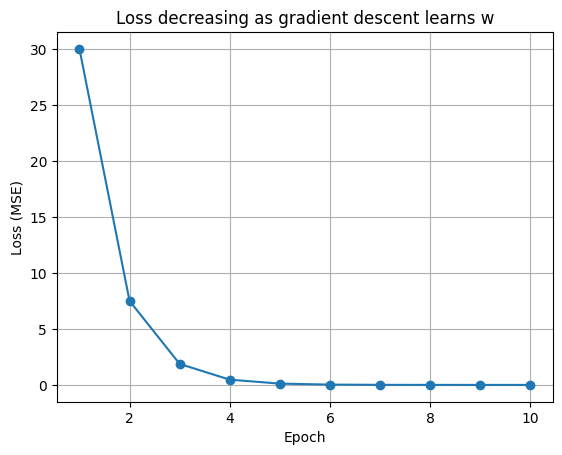

In [7]:
import matplotlib.pyplot as plt

# Learn w such that y = w * x approximates the true relationship y = 2x
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_true = torch.tensor([2.0, 4.0, 6.0, 8.0])

w = torch.tensor(0.0, requires_grad=True)   # start from a wrong guess
lr = 0.1
epochs = 10
loss_history = []

for epoch in range(epochs):
    # Forward pass
    y_pred = w * x
    loss = ((y_pred - y_true) ** 2).mean()

    # Backward pass -- computes d(loss)/dw and stores it in w.grad
    loss.backward()

    # Update step -- must NOT be tracked by autograd
    with torch.no_grad():
        w -= lr * w.grad

    # Reset gradient -- otherwise next epoch's backward() would ADD to this one's
    w.grad.zero_()

    loss_history.append(loss.item())
    print(f'Epoch {epoch+1:2d}: w = {w.item():.4f}  loss = {loss.item():.4f}')

print(f'\nTrue w should converge toward 2.0. Learned w = {w.item():.4f}')

plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss decreasing as gradient descent learns w')
plt.grid(True)
plt.show()

## Section 5 — `detach()` and Inference Mode

Two ways to step outside the computation graph:

- **`tensor.detach()`** — returns a new tensor with the same data, but with
  the graph connection severed (`requires_grad=False`). Useful when you want
  a value without letting it drag its whole history along.
- **`with torch.no_grad():`** — disables tracking for an entire block.
  Standard practice when evaluating/predicting after training, since you
  don't need gradients and skipping graph-building saves memory and time.

In [8]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(5.0)

y = w * x
print(f'y.requires_grad : {y.requires_grad}')

# ── COMMON PITFALL — a tensor that requires_grad can't go straight to NumPy ──
try:
    y.numpy()
except RuntimeError as e:
    print(f'\ny.numpy() fails while requires_grad=True:\n  RuntimeError: {e}')

# ── .detach() — snapshot the VALUE, drop the graph connection ────────────────
y_detached = y.detach()
print(f'\ny_detached.requires_grad : {y_detached.requires_grad}   <- graph link removed')
print(f'y_detached.numpy() works  : {y_detached.numpy()}')
print(f'shares data with y        : {y_detached.data_ptr() == y.data_ptr()}')

# ── torch.no_grad() — disable tracking for a whole block (used at inference) ─
print('\n=== Inside torch.no_grad() ===')
with torch.no_grad():
    prediction = w * x
    print(f'prediction.requires_grad : {prediction.requires_grad}   <- never tracked, saves memory/compute')

# Common pattern: after training, evaluate the model without building graphs
def predict(w, x):
    with torch.no_grad():
        return w * x

print(f'\npredict(w, x) = {predict(w, x).item()}')

y.requires_grad : True

y.numpy() fails while requires_grad=True:
  RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

y_detached.requires_grad : False   <- graph link removed
y_detached.numpy() works  : 10.0
shares data with y        : True

=== Inside torch.no_grad() ===
prediction.requires_grad : False   <- never tracked, saves memory/compute

predict(w, x) = 10.0


## Section 6 — Preview: `torch.nn` and `torch.optim`

Everything above was done manually so you can see exactly what autograd is
doing. In practice, PyTorch code uses `torch.nn.Module` for the model and
`torch.optim` for the update step. Here's the *exact same* training loop
from Section 4, rewritten idiomatically — this is what Phase 3 builds on.

In [9]:
import torch.nn as nn

# Same problem as before (y = 2x), but using PyTorch's built-in tools.
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])       # nn.Linear expects 2D input: (batch, features)
y_true = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

model = nn.Linear(in_features=1, out_features=1, bias=False)   # replaces our manual w
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)         # replaces manual "w -= lr * w.grad"
criterion = nn.MSELoss()                                        # replaces manual ((pred-true)**2).mean()

for epoch in range(epochs):
    y_pred = model(x)                # forward pass
    loss = criterion(y_pred, y_true)

    optimizer.zero_grad()            # replaces w.grad.zero_()
    loss.backward()                  # same as before
    optimizer.step()                 # replaces "with torch.no_grad(): w -= lr * w.grad"

    print(f'Epoch {epoch+1:2d}: w = {model.weight.item():.4f}  loss = {loss.item():.4f}')

print('\nSame result as the manual loop, learned via nn.Linear + optim.SGD.')
print('This is exactly what Phase 3 (torch.nn) builds on.')

Epoch  1: w = 2.6177  loss = 11.4477
Epoch  2: w = 1.6911  loss = 2.8619
Epoch  3: w = 2.1544  loss = 0.7155
Epoch  4: w = 1.9228  loss = 0.1789
Epoch  5: w = 2.0386  loss = 0.0447
Epoch  6: w = 1.9807  loss = 0.0112
Epoch  7: w = 2.0097  loss = 0.0028
Epoch  8: w = 1.9952  loss = 0.0007
Epoch  9: w = 2.0024  loss = 0.0002
Epoch 10: w = 1.9988  loss = 0.0000

Same result as the manual loop, learned via nn.Linear + optim.SGD.
This is exactly what Phase 3 (torch.nn) builds on.


## Phase 2 Summary

```
Autograd Core:
  requires_grad=True       -> track this tensor's operations
  tensor.grad_fn            -> which op created this tensor
  tensor.is_leaf             -> True for user-created tensors
  loss.backward()            -> compute all gradients via the chain rule
  tensor.grad                 -> the computed gradient (None until backward() runs)

Updating Parameters:
  with torch.no_grad():
      w -= lr * w.grad        -> update step must NOT be tracked
  w.grad.zero_()               -> REQUIRED before the next backward() (grads accumulate!)

Inference / No-Tracking:
  tensor.detach()               -> new tensor, same data, no graph link
  with torch.no_grad(): ...      -> disable tracking for a whole block

Idiomatic PyTorch (Phase 3 preview):
  model = nn.Linear(...)         -> replaces a manual w
  optimizer = torch.optim.SGD(model.parameters(), lr=...)
  optimizer.zero_grad() / loss.backward() / optimizer.step()

Common Pitfalls:
  - Forgetting w.grad.zero_()  -> gradients silently accumulate across epochs
  - In-place update on a leaf tensor OUTSIDE no_grad()  -> RuntimeError
  - Calling .numpy() on a tensor that still requires_grad, without
    .detach() first  -> RuntimeError
```